In [ ]:
# Create directories
!mkdir -p coco/images
!mkdir -p coco/annotations

# Download validation images (~1GB)
!wget http://images.cocodataset.org/zips/val2017.zip
!unzip val2017.zip -d coco/images
!rm val2017.zip

# Download training images (~18GB)
!wget http://images.cocodataset.org/zips/train2017.zip
!unzip train2017.zip -d coco/images
!rm train2017.zip

# Download annotations
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip annotations_trainval2017.zip -d coco/annotations
!rm annotations_trainval2017.zip


Streaming output truncated to the last 5000 lines.
 extracting: coco/images/train2017/000000249290.jpg  
 extracting: coco/images/train2017/000000025529.jpg  
 extracting: coco/images/train2017/000000316928.jpg  
 extracting: coco/images/train2017/000000337866.jpg  
 extracting: coco/images/train2017/000000547768.jpg  
 extracting: coco/images/train2017/000000423162.jpg  
 extracting: coco/images/train2017/000000224149.jpg  
 extracting: coco/images/train2017/000000117841.jpg  
 extracting: coco/images/train2017/000000251660.jpg  
 extracting: coco/images/train2017/000000110997.jpg  
 extracting: coco/images/train2017/000000424728.jpg  
 extracting: coco/images/train2017/000000384745.jpg  
 extracting: coco/images/train2017/000000475535.jpg  
 extracting: coco/images/train2017/000000252604.jpg  
 extracting: coco/images/train2017/000000002525.jpg  
 extracting: coco/images/train2017/000000547307.jpg  
 extracting: coco/images/train2017/000000546568.jpg  
 extracting: coco/images/train2

Load JSON Correctly

In [ ]:
import json

json_path = "coco/annotations/annotations/captions_val2017.json"

with open(json_path, "r") as f:
    coco_data = json.load(f)

print("Loaded successfully!")
print("Number of captions:", len(coco_data["annotations"]))
print("Sample caption:", coco_data["annotations"][6]["caption"])


Loaded successfully!
Number of captions: 25014
Sample caption: A tan toilet and sink combination in a small room.


In [ ]:
import os

image_dir = "coco/images/val2017/"
print("Exists:", os.path.exists(image_dir))
print("Images:", len(os.listdir(image_dir)))
print("Samples:", os.listdir(image_dir)[:5])


Exists: True
Images: 5000
Samples: ['000000157213.jpg', '000000170595.jpg', '000000374982.jpg', '000000560880.jpg', '000000356169.jpg']


Save as a JSON File

In [ ]:
import json

# Save the dataset to a file
def save_dataset_as_json(dataset, file_path):
    with open(file_path, 'w') as f:
        json.dump(dataset, f)
    print(f"Dataset saved to {file_path}")

# Path to save the JSON file
output_json_path = "coco_dataset.json"

# Save the COCO data (captions)
save_dataset_as_json(coco_data, output_json_path)


Dataset saved to coco_dataset.json


Load the Saved JSON File

In [ ]:
# Load the saved JSON dataset
def load_dataset_from_json(file_path):
    with open(file_path, 'r') as f:
        dataset = json.load(f)
    return dataset

# Load the dataset
loaded_coco_data = load_dataset_from_json(output_json_path)
print("Dataset loaded successfully!")
print("Number of captions:", len(loaded_coco_data["annotations"]))
print("Sample caption:", loaded_coco_data["annotations"][6
                                                         ]["caption"])


Dataset loaded successfully!
Number of captions: 25014
Sample caption: A tan toilet and sink combination in a small room.


## Preprocessing

Image Preprocessing for CLIP

In [ ]:
# Install CLIP
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-qh4e6cgo
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-qh4e6cgo
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=2449becbfd3d60bfede0cf7ef2ba162af40315641bea6a30699dac81f7876370
  Stored in directory: /tmp/pip-ephem-wheel-cache-v7qs1p27/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


verify image path


In [ ]:
import clip
print(clip.__file__)
print(dir(clip))

/usr/local/lib/python3.12/dist-packages/clip/__init__.py
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'available_models', 'clip', 'load', 'model', 'simple_tokenizer', 'tokenize']


In [ ]:
import os

print("Contents of coco/:")
print(os.listdir("coco"))


Contents of coco/:
['annotations', 'images']


In [ ]:
# received path error so running this code to verify the image path

import os

# Check if the directory exists and list the files
image_dir = "coco/val2017/"
if os.path.exists(image_dir):
    print("Image directory exists!")
    print("Files:", os.listdir(image_dir)[:5])  # Print first 5 files for confirmation
else:
    print("Image directory does not exist. Check the download extraction process.")


Image directory does not exist. Check the download extraction process.


In [ ]:
import clip
from PIL import Image
import torch
import os
from tqdm import tqdm

# Load CLIP model and preprocessing
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
# FREEZE CLIP so that we only train the head
for p in model.parameters():
    p.requires_grad = False

# Path to the images and captions
image_dir = "coco/images/val2017/"
annotations_path = "coco/annotations/annotations/captions_val2017.json"

# Load the COCO captions
with open(annotations_path, "r") as f:
    coco_data = json.load(f)

# Create lists for storing embeddings
image_embeddings = []
text_embeddings = []

# Preprocess images and captions
for ann in tqdm(coco_data["annotations"]):
    # Image path: based on the image_id (formatting as per COCO dataset)
    image_path = os.path.join(image_dir, f"{ann['image_id']:012d}.jpg")  # Assuming 12-digit zero-padded image ID

    # Check if the image exists before processing
    if os.path.exists(image_path):
        # Open and preprocess the image
        image = Image.open(image_path)
        image_tensor = preprocess(image).unsqueeze(0).to(device)

        # Tokenize the caption
        text_input = clip.tokenize([ann["caption"]]).to(device)

        # Extract image and text embeddings
        with torch.no_grad():
            image_embedding = model.encode_image(image_tensor)
            text_embedding = model.encode_text(text_input)
            image_embedding = image_embedding / image_embedding.norm(dim=-1, keepdim=True)
            text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)

        # Append embeddings
        image_embeddings.append(image_embedding.cpu())
        text_embeddings.append(text_embedding.cpu())
    else:
        print(f"Warning: Image not found: {image_path}")

# Convert embeddings to tensors
image_embeddings = torch.stack(image_embeddings)
text_embeddings = torch.stack(text_embeddings)

print(f"Image embeddings shape: {image_embeddings.shape}")
print(f"Text embeddings shape: {text_embeddings.shape}")

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 81.5MiB/s]
100%|██████████| 25014/25014 [11:18<00:00, 36.88it/s]


Image embeddings shape: torch.Size([25014, 1, 512])
Text embeddings shape: torch.Size([25014, 1, 512])


Save Embeddings

In [ ]:
import torch

# Save embeddings to files
torch.save(image_embeddings, 'image_embeddings.pth')
torch.save(text_embeddings, 'text_embeddings.pth')

print("Embeddings saved successfully!")


Embeddings saved successfully!


# Model for Similarity Scoring

cosine similarity model,hinge loss for training

In [ ]:
import torch
import torch.nn as nn

class SimilarityModel(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, img_emb, txt_emb):
        # img_emb, txt_emb: [B, 512]
        x = img_emb * txt_emb          # element-wise interaction
        score = self.fc(x)             # [B, 1]
        return score.squeeze(1)        # [B]


In [ ]:
#class HingeLoss(nn.Module):
    #def __init__(self, margin=1.0):
     #   super().__init__()
      ##   self.margin = margin

    #def forward(self, scores, labels):
        # labels ∈ {+1, -1}
     #   loss = torch.clamp(self.margin - labels * scores, min=0)
      ##  return loss.mean()

# we use focal oss instead hinge loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction="none")

    def forward(self, logits, targets):
        # Removed .unsqueeze(1) to match input shape of logits
        bce = self.bce(logits, targets.float())
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

In [ ]:
#model_sim = SimilarityModel().to(device)
#criterion = HingeLoss(margin=1.0)

#optimizer = torch.optim.Adam(
   # model_sim.parameters(),
    #lr=1e-3,
    #weight_decay=1e-4
#)

model_sim = SimilarityModel().to(device)
criterion = FocalLoss(alpha=0.5, gamma=2)

optimizer = torch.optim.Adam(
    model_sim.parameters(),   # ONLY head exists anyway
    lr=1e-3,
    weight_decay=1e-4
)



In [ ]:
import random

def create_pairs(img_embs, txt_embs, negatives_per_pos=1):
    img_out = []
    txt_out = []
    labels = []

    N = len(img_embs)

    for i in range(N):
        # POSITIVE
        img_out.append(img_embs[i])
        txt_out.append(txt_embs[i])
        labels.append(1.0)

        # HARD NEGATIVE: pick nearby index (not random)
        for _ in range(negatives_per_pos):
            j = (i + random.randint(1, 20)) % N  # nearby = harder
            img_out.append(img_embs[i])
            txt_out.append(txt_embs[j])
            labels.append(0.0)

    img_out = torch.cat(img_out, dim=0)
    txt_out = torch.cat(txt_out, dim=0)
    labels = torch.tensor(labels)

    return img_out, txt_out, labels



Training Loop

In [ ]:
img_all, txt_all, labels = create_pairs(image_embeddings, text_embeddings)

img_all = torch.nn.functional.normalize(img_all, dim=1)
txt_all = torch.nn.functional.normalize(txt_all, dim=1)

img_all = img_all.float().to(device)
txt_all = txt_all.float().to(device)
labels = labels.float().to(device)   # ✅ ensure float labels

print(img_all.dtype)
print(txt_all.dtype)
print(next(model_sim.parameters()).dtype)

epochs = 20
batch_size = 256

for epoch in range(epochs):
    perm = torch.randperm(len(labels))
    total_loss = 0.0

    for i in range(0, len(labels), batch_size):
        idx = perm[i:i + batch_size]

        img_b = img_all[idx]
        txt_b = txt_all[idx]
        lbl_b = labels[idx]

        optimizer.zero_grad()

        scores = model_sim(img_b, txt_b).view(-1)  # ✅ force 1D
        loss = criterion(scores, lbl_b)            # ✅ same shape

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}: Loss = {total_loss:.4f}")

torch.float32
torch.float32
torch.float32
Epoch 1: Loss = 16.8497
Epoch 2: Loss = 16.6567
Epoch 3: Loss = 16.5618
Epoch 4: Loss = 16.5042
Epoch 5: Loss = 16.4667
Epoch 6: Loss = 16.4427
Epoch 7: Loss = 16.4246
Epoch 8: Loss = 16.4133
Epoch 9: Loss = 16.4057
Epoch 10: Loss = 16.4009
Epoch 11: Loss = 16.3973
Epoch 12: Loss = 16.3953
Epoch 13: Loss = 16.3943
Epoch 14: Loss = 16.3930
Epoch 15: Loss = 16.3935
Epoch 16: Loss = 16.3924
Epoch 17: Loss = 16.3917
Epoch 18: Loss = 16.3915
Epoch 19: Loss = 16.3917
Epoch 20: Loss = 16.3912


In [ ]:
model_sim.eval()

SimilarityModel(
  (fc): Linear(in_features=512, out_features=1, bias=True)
)

In [ ]:
with torch.no_grad():
    scores = model_sim(img_all, txt_all).squeeze()

    # Prediction rule:
    # score > 0 → matching pair
    # score <= 0 → non-matching pair
    preds = (scores > 0).long()

    accuracy = (preds == labels).float().mean()

print(f"Training Accuracy: {accuracy.item() * 100:.2f}%")

Training Accuracy: 88.40%


Professional Model

In [ ]:
import torch
import torch.nn as nn

class SimilarityModel(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim * 2, 512),  # 1024 → 512
            nn.ReLU(),
            nn.BatchNorm1d(512),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        )

    def forward(self, img_emb, txt_emb):
        x = torch.cat([img_emb, txt_emb], dim=1)
        return self.net(x)

In [ ]:
print("Image embeddings shape:", img_all.shape)
print("Text embeddings shape:", txt_all.shape)
print("Labels shape:", labels.shape)

Image embeddings shape: torch.Size([50028, 512])
Text embeddings shape: torch.Size([50028, 512])
Labels shape: torch.Size([50028])


In [ ]:
img_all = torch.nn.functional.normalize(img_all, dim=1)
txt_all = torch.nn.functional.normalize(txt_all, dim=1)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_sim = SimilarityModel(embed_dim=512).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_sim.parameters(), lr=5e-5)

In [ ]:
img_all = img_all.float().to(device)
txt_all = txt_all.float().to(device)
labels = labels.float().to(device)  # BCE requires float labels

In [ ]:
# Do this ONCE before training, not in the loop
img_all = img_all.squeeze(1)  # [50028, 1, 512] → [50028, 512]
txt_all = txt_all.squeeze(1)  # [50028, 1, 512] → [50028, 512]

epochs = 15
batch_size = 256

for epoch in range(epochs):
    model_sim.train()
    perm = torch.randperm(len(labels))
    total_loss = 0
    num_batches = 0

    for i in range(0, len(labels), batch_size):
        idx = perm[i:i + batch_size]

        img_b = img_all[idx]  # Now already [batch_size, 512]
        txt_b = txt_all[idx]  # Now already [batch_size, 512]
        lbl_b = labels[idx]

        if len(idx) < 2:
            continue

        optimizer.zero_grad()
        scores = model_sim(img_b, txt_b).squeeze()
        loss = criterion(scores, lbl_b)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

Epoch 1/15 | Loss: 0.6242
Epoch 2/15 | Loss: 0.4319
Epoch 3/15 | Loss: 0.3169
Epoch 4/15 | Loss: 0.2554
Epoch 5/15 | Loss: 0.2172
Epoch 6/15 | Loss: 0.1892
Epoch 7/15 | Loss: 0.1668
Epoch 8/15 | Loss: 0.1493
Epoch 9/15 | Loss: 0.1330
Epoch 10/15 | Loss: 0.1214
Epoch 11/15 | Loss: 0.1095
Epoch 12/15 | Loss: 0.1028
Epoch 13/15 | Loss: 0.0952
Epoch 14/15 | Loss: 0.0890
Epoch 15/15 | Loss: 0.0852


In [ ]:
model_sim.eval()
with torch.no_grad():
    scores = model_sim(img_all, txt_all).squeeze()
    probs = torch.sigmoid(scores)
    preds = (probs > 0.5).long()
    acc = (preds == labels.long()).float().mean()

print(f"Final Accuracy: {acc.item() * 100:.2f}%")

Final Accuracy: 97.15%


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ImprovedSimilarityModel(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()

        # Deeper network with residual-like connections
        self.fc1 = nn.Linear(embed_dim * 2, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.dropout3 = nn.Dropout(0.2)

        self.fc4 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.1)

        self.fc5 = nn.Linear(128, 1)

    def forward(self, img_emb, txt_emb):
        x = torch.cat([img_emb, txt_emb], dim=1)

        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout3(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.dropout4(x)

        x = self.fc5(x)
        return x


# Squeeze embeddings first
img_all = img_all.squeeze(1)
txt_all = txt_all.squeeze(1)

# Normalize embeddings
img_all = F.normalize(img_all, dim=1)
txt_all = F.normalize(txt_all, dim=1)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Create train/val split
from sklearn.model_selection import train_test_split

indices = torch.arange(len(labels))
train_idx, val_idx = train_test_split(
    indices.numpy(),
    test_size=0.15,
    random_state=42,
    stratify=labels.cpu().numpy()
)

train_idx = torch.LongTensor(train_idx)
val_idx = torch.LongTensor(val_idx)

# Move data to device
img_all = img_all.float().to(device)
txt_all = txt_all.float().to(device)
labels = labels.float().to(device)

# Initialize model
model_sim = ImprovedSimilarityModel(embed_dim=512).to(device)

# Use weighted loss if classes are imbalanced
pos_weight = (labels == 0).sum() / (labels == 1).sum()
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Improved optimizer with weight decay
optimizer = torch.optim.AdamW(model_sim.parameters(), lr=1e-4, weight_decay=1e-4)

# Learning rate scheduler (removed verbose parameter)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

epochs = 30
batch_size = 256
best_val_acc = 0

for epoch in range(epochs):
    # Training
    model_sim.train()
    perm = train_idx[torch.randperm(len(train_idx))]
    total_loss = 0
    num_batches = 0

    for i in range(0, len(perm), batch_size):
        idx = perm[i:i + batch_size]
        if len(idx) < 2:
            continue

        img_b = img_all[idx]
        txt_b = txt_all[idx]
        lbl_b = labels[idx]

        optimizer.zero_grad()
        scores = model_sim(img_b, txt_b).squeeze()
        loss = criterion(scores, lbl_b)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model_sim.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_train_loss = total_loss / num_batches if num_batches > 0 else 0

    # Validation
    model_sim.eval()
    with torch.no_grad():
        val_scores = []
        val_labels_list = []

        for i in range(0, len(val_idx), batch_size):
            idx = val_idx[i:i + batch_size]

            img_b = img_all[idx]
            txt_b = txt_all[idx]
            lbl_b = labels[idx]

            scores = model_sim(img_b, txt_b).squeeze()
            preds = torch.sigmoid(scores)

            val_scores.append(preds)
            val_labels_list.append(lbl_b)

        val_scores = torch.cat(val_scores)
        val_labels_cat = torch.cat(val_labels_list)

        val_preds = (val_scores > 0.5).float()
        val_acc = (val_preds == val_labels_cat).float().mean().item()

        # Calculate precision, recall
        tp = ((val_preds == 1) & (val_labels_cat == 1)).sum().item()
        fp = ((val_preds == 1) & (val_labels_cat == 0)).sum().item()
        tn = ((val_preds == 0) & (val_labels_cat == 0)).sum().item()
        fn = ((val_preds == 0) & (val_labels_cat == 1)).sum().item()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # Update learning rate and check if it changed
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != old_lr:
        print(f"Learning rate reduced from {old_lr:.6f} to {new_lr:.6f}")

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | Precision: {precision:.4f} | "
          f"Recall: {recall:.4f} | F1: {f1:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_sim.state_dict(), 'best_similarity_model.pth')
        print(f"\u2713 Best model saved with accuracy: {best_val_acc:.4f}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 1/30 | Train Loss: 0.6182 | Val Acc: 0.8281 | Precision: 0.7565 | Recall: 0.9678 | F1: 0.8492
✓ Best model saved with accuracy: 0.8281
Epoch 2/30 | Train Loss: 0.4006 | Val Acc: 0.8810 | Precision: 0.8151 | Recall: 0.9856 | F1: 0.8923
✓ Best model saved with accuracy: 0.8810
Epoch 3/30 | Train Loss: 0.3048 | Val Acc: 0.8990 | Precision: 0.8405 | Recall: 0.9848 | F1: 0.9070
✓ Best model saved with accuracy: 0.8990
Epoch 4/30 | Train Loss: 0.2568 | Val Acc: 0.9054 | Precision: 0.8484 | Recall: 0.9872 | F1: 0.9125
✓ Best model saved with accuracy: 0.9054
Epoch 5/30 | Train Loss: 0.2286 | Val Acc: 0.9133 | Precision: 0.8600 | Recall: 0.9872 | F1: 0.9192
✓ Best model saved with accuracy: 0.9133
Epoch 6/30 | Train Loss: 0.2090 | Val Acc: 0.9141 | Precision: 0.8622 | Recall: 0.9856 | F1: 0.9198
✓ Best model saved with accuracy: 0.9141
Epoch 7/30 | Train Loss: 0.1907 | Val Acc: 0.9166 | Precision: 0.8674 | Recall: 0.9835 | F1: 0.9218
✓ Best model saved with accuracy: 0.9166
Epoch 8/30 | 

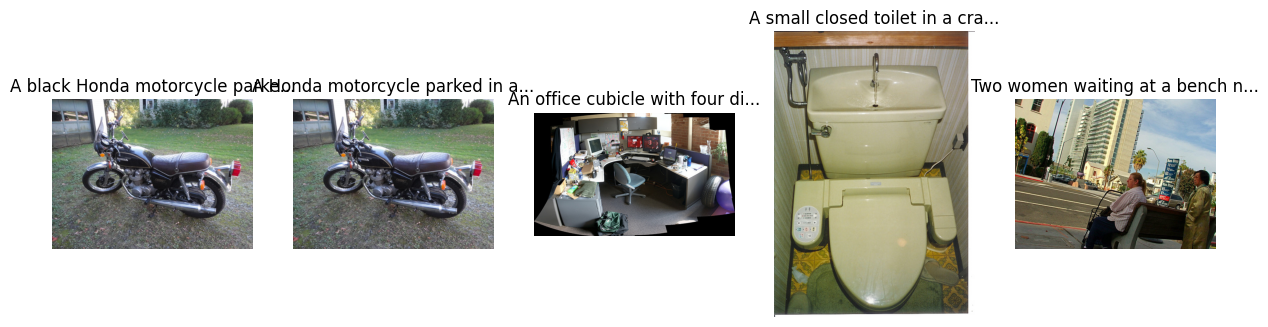

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import json
import os

# Paths to your COCO dataset
image_dir = "coco/images/val2017/"
annotations_path = "coco/annotations/annotations/captions_val2017.json"

# Load COCO captions
with open(annotations_path, "r") as f:
    coco_data = json.load(f)

# Pick some random samples (say 5)
sample_annotations = coco_data["annotations"][:5]  # first 5, can randomize too

plt.figure(figsize=(15, 8))

for i, ann in enumerate(sample_annotations):
    img_id = ann["image_id"]
    caption = ann["caption"]
    img_path = os.path.join(image_dir, f"{img_id:012d}.jpg")

    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(caption[:30] + "...")  # truncate long captions
        plt.axis('off')

plt.show()


In [ ]:
import torch
from PIL import Image
import clip
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# 1️⃣ Define ImprovedSimilarityModel
# -----------------------------
class ImprovedSimilarityModel(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(embed_dim * 2, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.dropout3 = nn.Dropout(0.2)

        self.fc4 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.1)

        self.fc5 = nn.Linear(128, 1)

    def forward(self, img_emb, txt_emb):
        x = torch.cat([img_emb, txt_emb], dim=1)
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        x = F.relu(self.bn4(self.fc4(x)))
        x = self.dropout4(x)
        x = self.fc5(x)
        return x

# -----------------------------
# 2️⃣ Load CLIP and your trained similarity model
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = clip.load("ViT-B/32", device=device)

similarity_model = ImprovedSimilarityModel(embed_dim=512)
similarity_model.load_state_dict(torch.load("best_similarity_model.pth", map_location=device))
similarity_model.to(device)
similarity_model.eval()

# -----------------------------
# 3️⃣ Inference function
# -----------------------------
def predict_image_caption_match(image_path, caption):
    # Robustly open image (handles .jfif, .jpg, .png)
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess(image).unsqueeze(0).to(device)

    text_tensor = clip.tokenize([caption]).to(device)

    with torch.no_grad():
        # Get embeddings and convert to float32 to match model
        img_emb = clip_model.encode_image(image_tensor).float()
        txt_emb = clip_model.encode_text(text_tensor).float()

        # Normalize embeddings
        img_emb /= img_emb.norm(dim=-1, keepdim=True)
        txt_emb /= txt_emb.norm(dim=-1, keepdim=True)

        # Predict similarity
        score = torch.sigmoid(similarity_model(img_emb, txt_emb))

    return score.item()

# -----------------------------
# 4️⃣ Interactive usage
# -----------------------------
# For Google Colab
try:
    from google.colab import files
    uploaded = files.upload()
    image_path = list(uploaded.keys())[0]
except ImportError:
    image_path = input("Enter local image path: ")

caption = input("Enter a caption for the image: ")

prob = predict_image_caption_match(image_path, caption)
print(f"\nMatching probability: {prob:.2f}")

if prob > 0.5:
    print("✅ Caption matches the image")
else:
    print("❌ Caption does NOT match the image")


Saving land.jfif to land.jfif
Enter a caption for the image: football 

Matching probability: 0.01
❌ Caption does NOT match the image


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
